# Phase 2 — Exploratory Data Analysis (EDA)
**Project: What Does Underground Sound Like?**

EDA means: *look at the data visually before building any model*. The goal is to find patterns and build intuition. We'll answer:
- What does the 'sound profile' of underground music look like vs mainstream?
- Which audio features differ most between the two groups?
- Are there genre differences?

## Cell 1 — Imports and load data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np

%matplotlib inline
sns.set_theme(style='whitegrid', palette='muted')

# Load the clean file from Phase 1
df = pd.read_csv('df_clean.csv')
df_model = pd.read_csv('df_model.csv')  # underground + mainstream only

# Separate into two groups — makes chart code cleaner
underground = df_model[df_model['label'] == 'underground']
mainstream  = df_model[df_model['label'] == 'mainstream']

# The 12 audio features we'll analyse
AUDIO_FEATURES = [
    'danceability', 'energy', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness',
    'valence', 'tempo', 'loudness',
    'duration_ms'
]

# Colors — consistent throughout all charts
C_UNDERGROUND = '#5B4CF0'  # purple
C_MAINSTREAM  = '#E8593C'  # coral

print(f'Loaded: {len(underground):,} underground songs, {len(mainstream):,} mainstream songs')

Loaded: 6,483 underground songs, 6,838 mainstream songs


---
## Cell 2 — Radar chart: the 'sound DNA' of each group
A radar (spider) chart puts all audio features on one plot. Each axis is one feature. The shape of each group's polygon IS its sound profile. This is the centrepiece chart of your project.

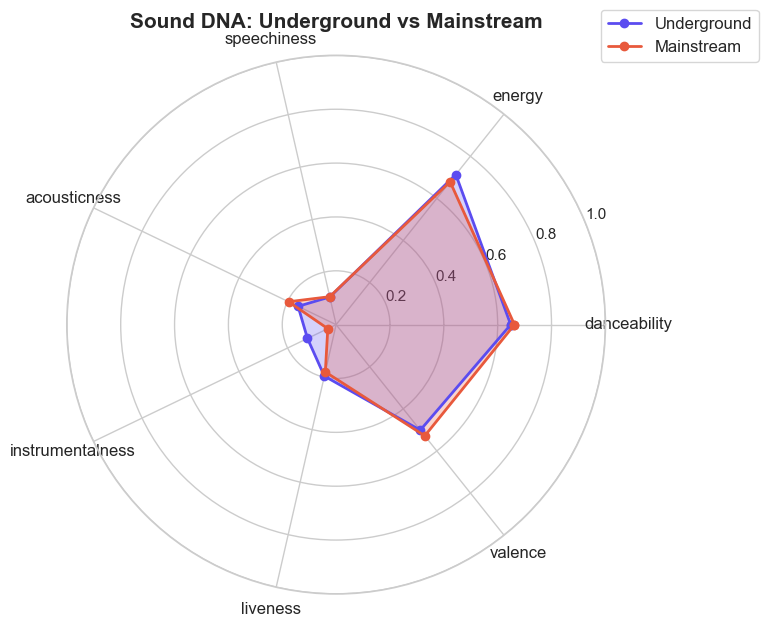

Mean audio features by group:
         Feature  Underground  Mainstream  Difference
    danceability        0.648       0.662      -0.014
          energy        0.713       0.679       0.034
     speechiness        0.105       0.107      -0.002
    acousticness        0.157       0.196      -0.039
instrumentalness        0.118       0.034       0.084
        liveness        0.196       0.180       0.016
         valence        0.501       0.528      -0.027


In [2]:
# Features to include on the radar (skip tempo/loudness/duration — different scales)
radar_features = ['danceability', 'energy', 'speechiness',
                  'acousticness', 'instrumentalness', 'liveness', 'valence']

# Calculate the mean value of each feature per group
# This is the 'average sound' of underground vs mainstream
underground_means = underground[radar_features].mean().values
mainstream_means  = mainstream[radar_features].mean().values

# Radar charts need the data to 'close the loop' — repeat the first value at the end
underground_means = np.concatenate([underground_means, [underground_means[0]]])
mainstream_means  = np.concatenate([mainstream_means,  [mainstream_means[0]]])

# Calculate the angle for each feature (evenly spaced around the circle)
N = len(radar_features)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the loop

# Draw the radar chart
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# Plot underground
ax.plot(angles, underground_means, 'o-', linewidth=2, color=C_UNDERGROUND, label='Underground')
ax.fill(angles, underground_means, alpha=0.25, color=C_UNDERGROUND)

# Plot mainstream
ax.plot(angles, mainstream_means, 'o-', linewidth=2, color=C_MAINSTREAM, label='Mainstream')
ax.fill(angles, mainstream_means, alpha=0.25, color=C_MAINSTREAM)

# Add feature labels at each axis
ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_features, size=12)

ax.set_ylim(0, 1)
ax.set_title('Sound DNA: Underground vs Mainstream', size=15, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=12)

plt.tight_layout()
plt.savefig('output_radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()

# Print the actual numbers so you can discuss them
print('Mean audio features by group:')
comparison = pd.DataFrame({
    'Feature': radar_features,
    'Underground': underground[radar_features].mean().round(3).values,
    'Mainstream':  mainstream[radar_features].mean().round(3).values
})
comparison['Difference'] = (comparison['Underground'] - comparison['Mainstream']).round(3)
print(comparison.to_string(index=False))

---
## Cell 3 — Feature distribution: side-by-side violin plots
Box plots show medians. Violin plots show the *whole distribution shape* — much more informative.

C:\Users\hige\AppData\Local\Temp\ipykernel_26892\2142451119.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_data, x='label', y=feature, ax=ax,
C:\Users\hige\AppData\Local\Temp\ipykernel_26892\2142451119.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_data, x='label', y=feature, ax=ax,
C:\Users\hige\AppData\Local\Temp\ipykernel_26892\2142451119.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_data, x='label', y=feature, ax=ax,
C:\Users\hige\AppData\Local\Temp\ipykernel_26892\2142451119.py:1

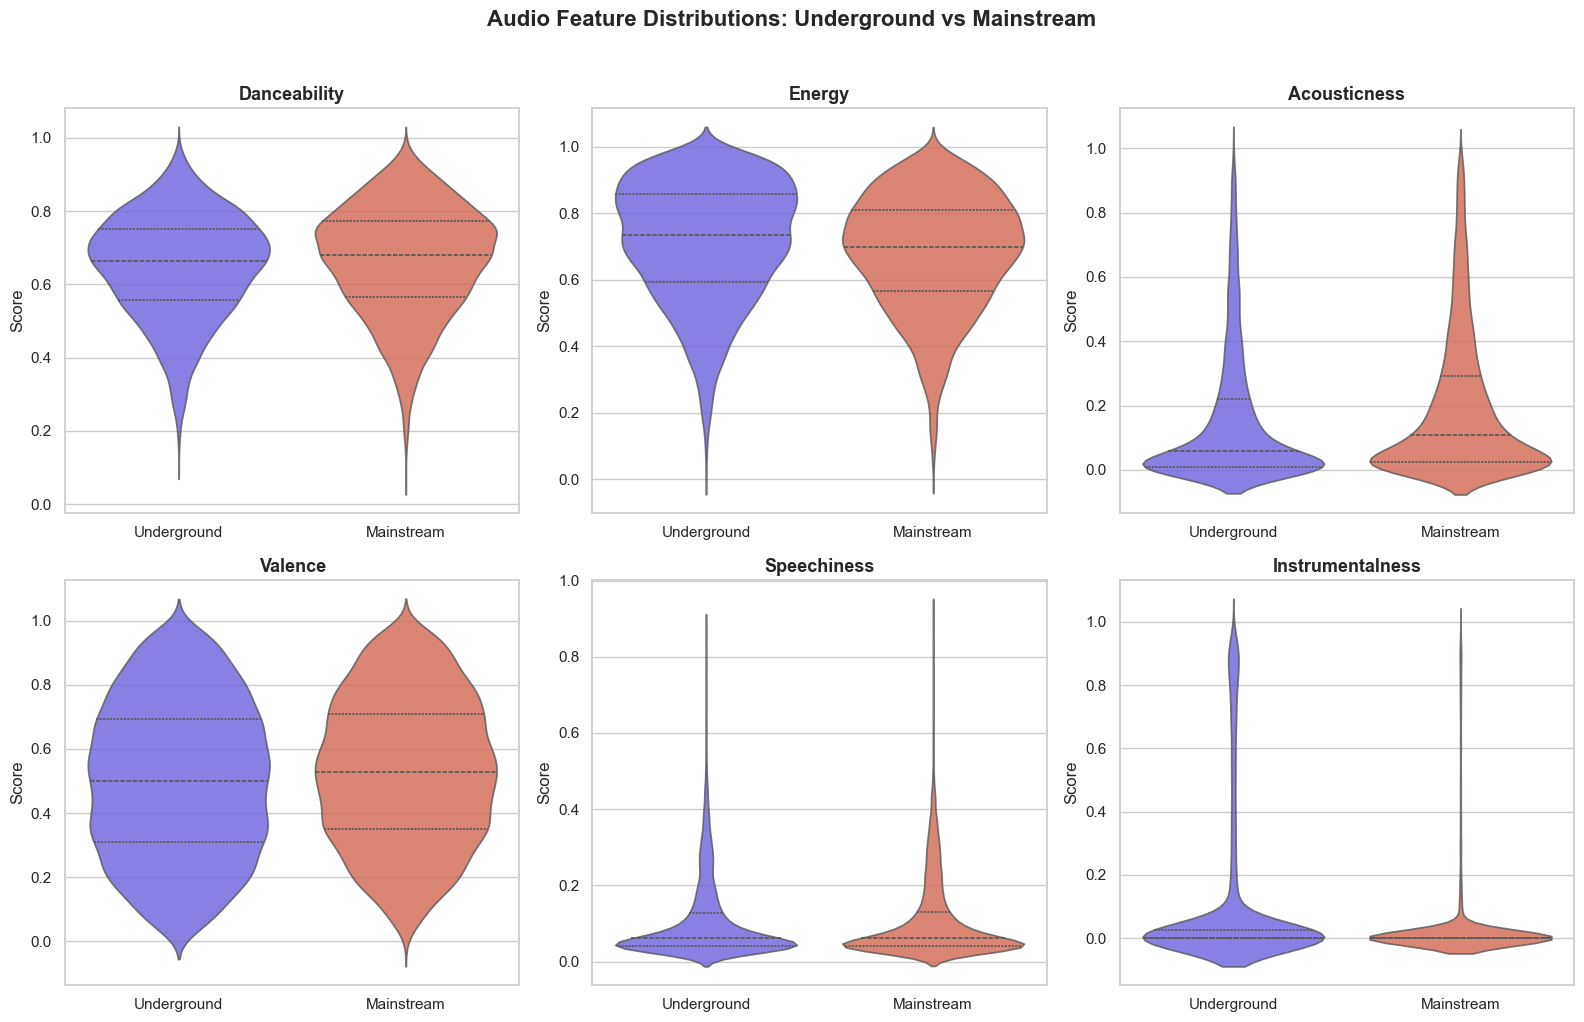

In [3]:
# Pick the most interesting features to compare
compare_features = ['danceability', 'energy', 'acousticness', 'valence', 'speechiness', 'instrumentalness']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()  # Convert 2D array to 1D for easy looping

for i, feature in enumerate(compare_features):
    ax = axes[i]
    
    # Combine the data into one DataFrame for seaborn
    plot_data = pd.concat([
        underground[[feature]].assign(label='Underground'),
        mainstream[[feature]].assign(label='Mainstream')
    ])
    
    # Violin plot — the wide part shows where most songs cluster
    sns.violinplot(data=plot_data, x='label', y=feature, ax=ax,
                   palette={'Underground': C_UNDERGROUND, 'Mainstream': C_MAINSTREAM},
                   alpha=0.8, inner='quartile')  # inner='quartile' shows median + IQR inside
    
    ax.set_title(feature.capitalize(), fontsize=13, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Score')

plt.suptitle('Audio Feature Distributions: Underground vs Mainstream',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('output_violin_plots.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Cell 4 — Correlation heatmap
A heatmap shows how features relate to each other. If danceability and energy both go up together, they're positively correlated. This helps us pick which features matter most for the model.

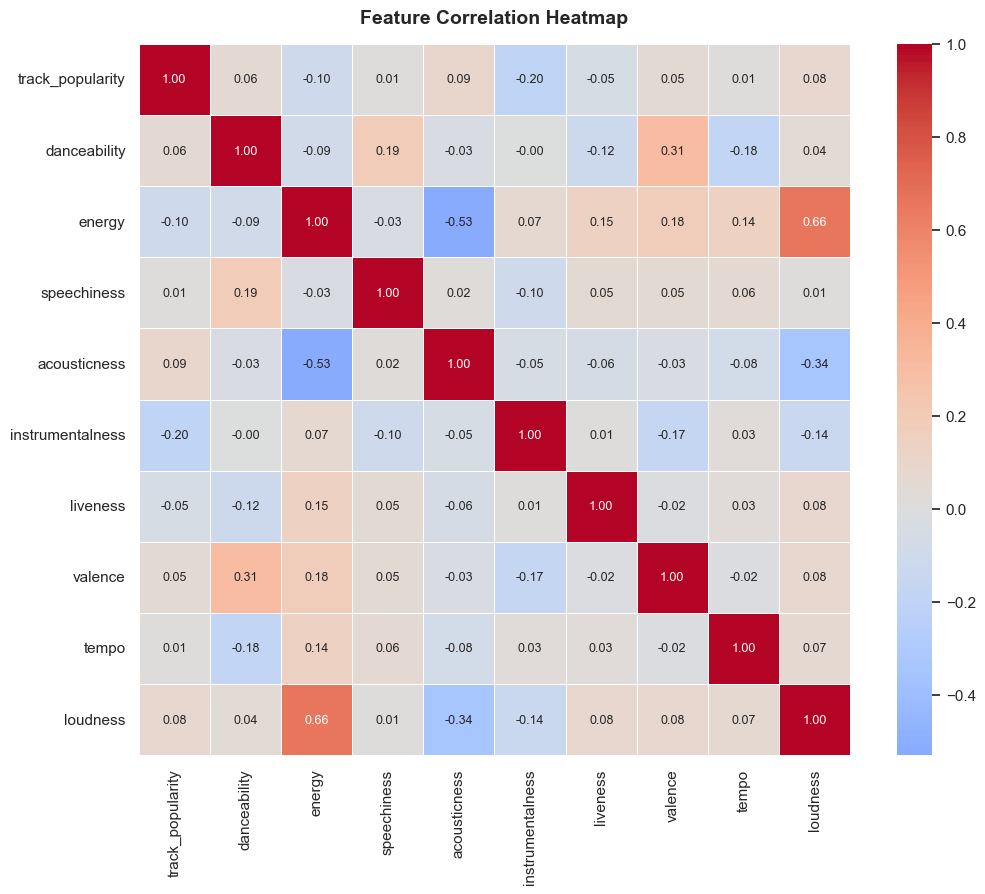

Correlation with track_popularity (sorted):
  acousticness        : +0.090  ↑ positive
  loudness            : +0.080  ↑ positive
  danceability        : +0.060  ↑ positive
  valence             : +0.050  → neutral
  speechiness         : +0.010  → neutral
  tempo               : +0.010  → neutral
  liveness            : -0.050  → neutral
  energy              : -0.100  ↓ negative
  instrumentalness    : -0.200  ↓ negative


In [4]:
# Select only the numeric audio features
corr_features = ['track_popularity', 'danceability', 'energy', 'speechiness',
                 'acousticness', 'instrumentalness', 'liveness', 'valence',
                 'tempo', 'loudness']

# .corr() calculates the correlation matrix (values from -1 to +1)
# +1 = perfectly move together, -1 = perfectly opposite, 0 = no relationship
corr_matrix = df_model[corr_features].corr().round(2)

fig, ax = plt.subplots(figsize=(11, 9))

# Draw the heatmap
# annot=True puts the number inside each cell
# cmap='coolwarm' = blue (negative) to red (positive)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, fmt='.2f',
            annot_kws={'size': 9}, ax=ax)

ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('output_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Print the features most correlated with popularity
print('Correlation with track_popularity (sorted):')
pop_corr = corr_matrix['track_popularity'].drop('track_popularity').sort_values(ascending=False)
for feat, val in pop_corr.items():
    direction = '↑ positive' if val > 0.05 else ('↓ negative' if val < -0.05 else '→ neutral')
    print(f'  {feat:20s}: {val:+.3f}  {direction}')

---
## Cell 5 — Genre breakdown
Are underground songs more common in certain genres? This adds a cultural layer to the analysis.

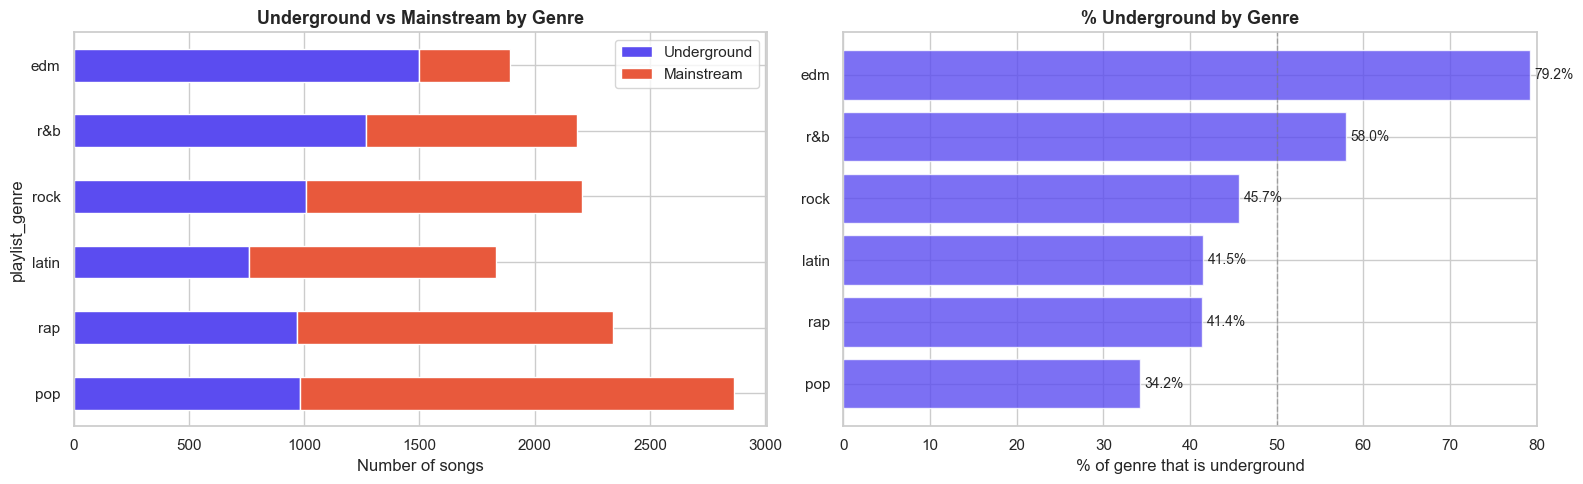

In [5]:
# Count songs per genre per label, then calculate the underground % per genre
genre_label = df_model.groupby(['playlist_genre', 'label']).size().unstack(fill_value=0)

# Calculate what % of each genre is 'underground'
genre_label['total'] = genre_label.sum(axis=1)
genre_label['underground_pct'] = (genre_label['underground'] / genre_label['total'] * 100).round(1)
genre_label = genre_label.sort_values('underground_pct', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: stacked bar by genre
genre_plot = genre_label[['underground', 'mainstream']].copy()
genre_plot.plot(kind='barh', stacked=True, ax=axes[0],
                color=[C_UNDERGROUND, C_MAINSTREAM], edgecolor='white')
axes[0].set_title('Underground vs Mainstream by Genre', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of songs')
axes[0].legend(['Underground', 'Mainstream'])

# Right: % underground per genre — immediately tells the story
bars = axes[1].barh(genre_label.index, genre_label['underground_pct'],
                    color=C_UNDERGROUND, alpha=0.8, edgecolor='white')
axes[1].axvline(50, color='gray', linestyle='--', linewidth=1, alpha=0.6, label='50% line')
axes[1].set_title('% Underground by Genre', fontsize=13, fontweight='bold')
axes[1].set_xlabel('% of genre that is underground')
axes[1].set_xlim(0, 80)

# Add percentage labels to bars
for bar, (_, row) in zip(bars, genre_label.iterrows()):
    axes[1].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                 f"{row['underground_pct']}%", va='center', fontsize=10)

plt.tight_layout()
plt.savefig('output_genre_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Cell 6 — Key EDA findings summary
Before moving to the model, write down what you found. This is your data story.

In [6]:
# Auto-generate a findings summary from the data
feature_diffs = {}
for feature in ['danceability', 'energy', 'acousticness', 'valence', 'speechiness', 'instrumentalness']:
    ug_mean = underground[feature].mean()
    ms_mean = mainstream[feature].mean()
    diff = ((ug_mean - ms_mean) / ms_mean * 100)
    feature_diffs[feature] = (ug_mean, ms_mean, diff)

print('=== EDA FINDINGS SUMMARY ===')
print('(Use these to write your README and explain to recruiters)\n')

for feature, (ug, ms, diff) in sorted(feature_diffs.items(), key=lambda x: abs(x[1][2]), reverse=True):
    direction = 'HIGHER' if diff > 0 else 'LOWER'
    print(f'  {feature.capitalize():18s}: underground is {direction} by {abs(diff):.1f}%  (UG: {ug:.3f} vs MS: {ms:.3f})')

print()
most_underground_genre = genre_label['underground_pct'].idxmax()
least_underground_genre = genre_label['underground_pct'].idxmin()
print(f'  Most underground genre:  {most_underground_genre} ({genre_label.loc[most_underground_genre, "underground_pct"]}%)')
print(f'  Most mainstream genre:   {least_underground_genre} ({genre_label.loc[least_underground_genre, "underground_pct"]}%)')
print()
print('✅ Phase 2 complete! Move to phase3_model.ipynb')

=== EDA FINDINGS SUMMARY ===
(Use these to write your README and explain to recruiters)

  Instrumentalness  : underground is HIGHER by 244.7%  (UG: 0.118 vs MS: 0.034)
  Acousticness      : underground is LOWER by 20.0%  (UG: 0.157 vs MS: 0.196)
  Valence           : underground is LOWER by 5.1%  (UG: 0.501 vs MS: 0.528)
  Energy            : underground is HIGHER by 5.0%  (UG: 0.713 vs MS: 0.679)
  Danceability      : underground is LOWER by 2.1%  (UG: 0.648 vs MS: 0.662)
  Speechiness       : underground is LOWER by 1.0%  (UG: 0.105 vs MS: 0.107)

  Most underground genre:  edm (79.2%)
  Most mainstream genre:   pop (34.2%)

✅ Phase 2 complete! Move to phase3_model.ipynb
